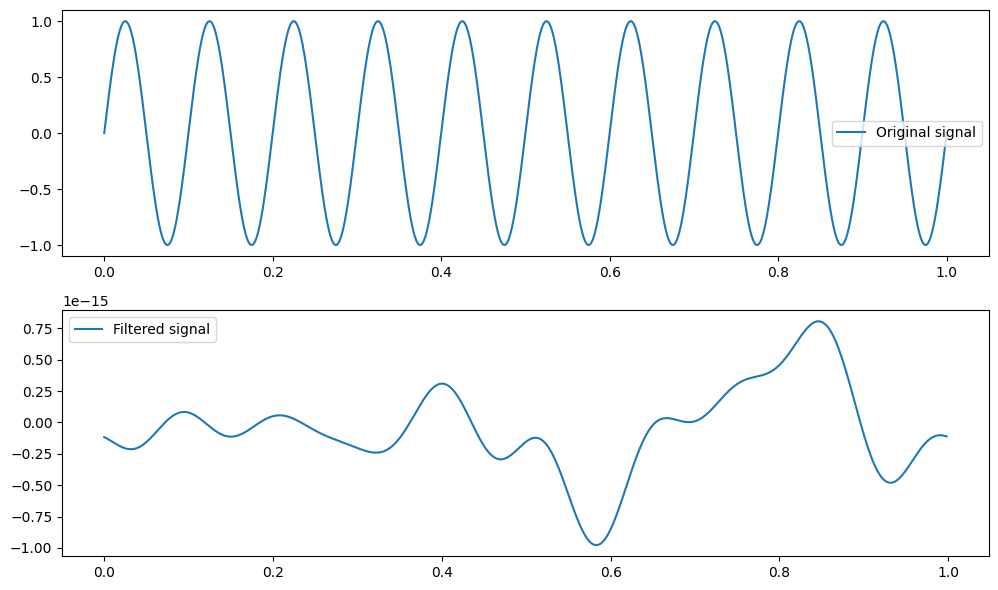

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

# Define the function for the signal
def f(t):
    return np.sin(2*np.pi*10 * t)

# Define the time vector with a very high sampling rate
t = np.linspace(0, 1, 10000)

# Sample the signal
t_sampled = np.linspace(0, 1, 500, endpoint=False)
y_original = f(t)
y_sampled = f(t_sampled)

# Compute the FFT of the sampled signal
y_fft = fft(y_sampled)

# Define the low-pass filter
# Here, we zero out all frequencies above a cutoff
cutoff = 10  # Adjust this to change the cutoff frequency
y_fft_filtered = np.array(y_fft).copy()
y_fft_filtered[cutoff:] = 0

# Compute the IFFT of the filtered signal
y_filtered =  np.real(ifft(y_fft_filtered, n=len(y_fft_filtered)))

# Plot the original and filtered signals
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y_original, label='Original signal')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_sampled, y_filtered, label='Filtered signal')
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
import holidays as hd
import pandas as pd

haryana_holidays = hd.IN

In [19]:
for date, name in sorted(haryana_holidays( subdiv = 'HR', years = 2023).items()):
    
    print(date, name)



2023-01-14 Makar Sankranti / Pongal
2023-01-26 Republic Day
2023-03-08 Holi
2023-04-02 Palm Sunday
2023-04-07 Good Friday
2023-04-09 Easter Sunday
2023-04-14 Dr. B. R. Ambedkar's Jayanti
2023-04-21 Eid ul-Fitr* (*estimated)
2023-04-22 Eid ul-Fitr* (*estimated)
2023-05-01 Labour Day
2023-05-28 Feast of Pentecost
2023-06-28 Eid al-Adha* (*estimated)
2023-06-29 Eid al-Adha* (*estimated)
2023-07-28 Day of Ashura* (*estimated)
2023-08-15 Independence Day
2023-09-27 Mawlid* (*estimated)
2023-10-02 Gandhi Jayanti
2023-11-01 Haryana Foundation Day
2023-11-12 Diwali
2023-12-25 Christmas Day


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
register_matplotlib_converters()
import seaborn as sns
import statsmodels.api as sm

In [26]:


def plot_all_graphs(data, var = 'load_data'):

    # Plot line plot of the data
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=data.index, y=data[var])
    plt.title('Line Plot of Data')
    plt.xlabel('Time')
    plt.ylabel('Data')
    plt.show()

    # Plot seasonal plot of the data
    plt.figure(figsize=(10, 6))
    sm.graphics.tsa.seasonal_plot(data, xticklabels='auto')
    plt.title('Seasonal Plot of Data')
    plt.xlabel('Month')
    plt.ylabel('Data')
    plt.show()

    # Plot density plot of the data
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data, shade=True)
    plt.title('Density Plot of Data')
    plt.xlabel('Data')
    plt.ylabel('Density')
    plt.show()

    # Plot autocorrelation plot of the data
    plt.figure(figsize=(10, 6))
    sm.graphics.tsa.plot_acf(data, lags=24)
    plt.title('Autocorrelation Plot of Data')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.show()

    # Plot partial autocorrelation plot of the data
    plt.figure(figsize=(10, 6))
    sm.graphics.tsa.plot_pacf(data, lags=24)
    plt.title('Partial Autocorrelation Plot of Data')
    plt.xlabel('Lag')
    plt.ylabel('Partial Autocorrelation')
    plt.show()

    # Plot polar plot of the data
    plt.figure(figsize=(10, 6))
    plt.polar(data.index, data)
    plt.title('Polar Plot of Data')
    plt.xlabel('Month')
    plt.ylabel('Data')
    plt.show()

    # Plot moving average plot of the data
    plt.figure(figsize=(10, 6))
    data.rolling(7).mean().plot()
    plt.title('Moving Average Plot of Data')
    plt.xlabel('Time')
    plt.ylabel('Data')
    plt.show()


In [7]:
def get_start_end_data(df):
    start_missing = df.isnull().idxmax()[0]
    final_missing = df[::-1].isnull().idxmax()[0]
    start_data = df.iloc[:df.index.get_loc(start_missing)]
    end_data = df.iloc[df.index.get_loc(final_missing)+1:]
    return start_data, end_data

In [9]:
def plot_load_data_acf_pacf(Load_df, days, lags):
    # get data for specified number of days
    # end_date = pd.to_datetime(days)
    df = Load_df.iloc[:days*96]
    
    # plot load data
    plt.figure(figsize=(20,4))
    plt.plot(df.load_data)
    plt.title('Traction Load', fontsize=20)
    plt.ylabel('Load', fontsize=16)
    # ax = plt.gca()
    
    # # add vertical lines to indicate start of each day
    # for i in range(days):
    #     ax.axvline(x=i*96, color='r', linestyle='--', alpha=0.3)
    
    # lags
    lags = 96*lags
    # plot ACF
    acf_plot = plot_acf(df.load_data, lags=lags)
    fig = acf_plot.get_figure()
    fig.set_size_inches(20, 5)
    ax = fig.gca()
    for i in range(lags//96):
        ax.axvline(x=96*i, color='r', linestyle='--', alpha=0.3)
    
    # plot PACF
    pacf_plot = plot_pacf(df.load_data, lags=lags)
    fig = pacf_plot.get_figure()
    fig.set_size_inches(20, 5)
    ax = fig.gca()
    for i in range(lags//96):
        ax.axvline(x=96*i, color='r', linestyle='--', alpha=0.3)
    
    # show plots
    plt.show()


In [3]:
Load_df = pd.read_excel('output.xlsx', index_col='date', parse_dates=True)

In [4]:
Load_df.head()

,load_data,day
date,,
2022-04-01 00:15:00,16.07,Friday
2022-04-01 00:30:00,13.75,Friday
2022-04-01 00:45:00,13.13,Friday
2022-04-01 01:00:00,10.36,Friday
2022-04-01 01:15:00,9.96,Friday


Text(0, 0.5, 'Load')

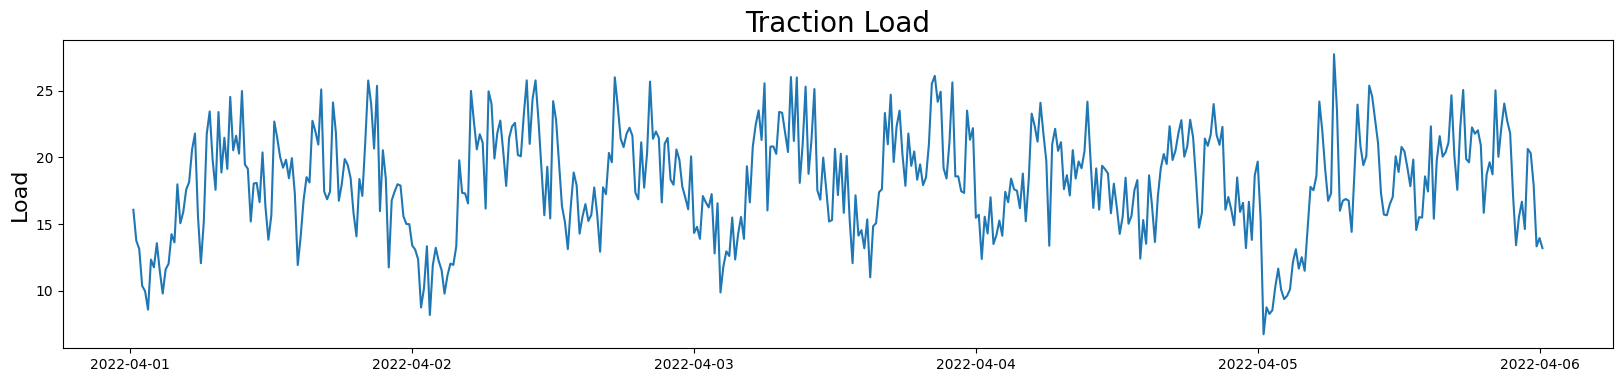

In [5]:
end_date = pd.to_datetime('2022-04-06 00:23:45')
df = Load_df[:end_date]
plt.figure(figsize=(20,4))
plt.plot(df.load_data)
# plt.plot(df.load_data.rolling(96).mean())

plt.title('Traction Load', fontsize=20)
plt.ylabel('Load', fontsize=16)
# smooth by rolling mean

In [8]:
df1,df2 = get_start_end_data(Load_df)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3320707166.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start_missing = df.isnull().idxmax()[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_18364\3320707166.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_missing = df[::-1].isnull().idxmax()[0]


In [17]:
data = Load_df.iloc[:96*7]
data = data.drop(columns=['day'])
data.head()

,load_data
date,
2022-04-01 00:15:00,16.07
2022-04-01 00:30:00,13.75
2022-04-01 00:45:00,13.13
2022-04-01 01:00:00,10.36
2022-04-01 01:15:00,9.96


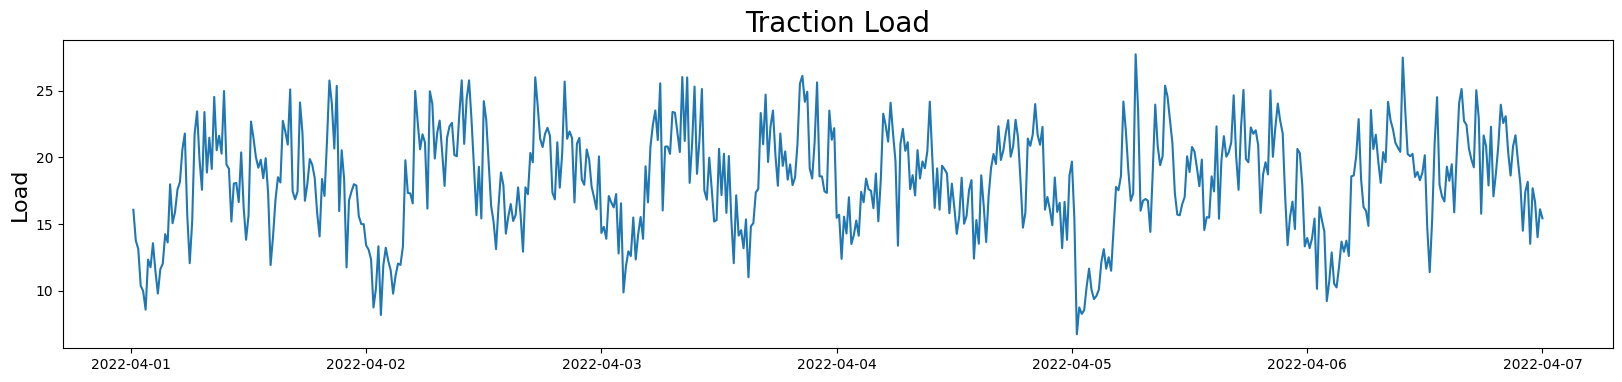

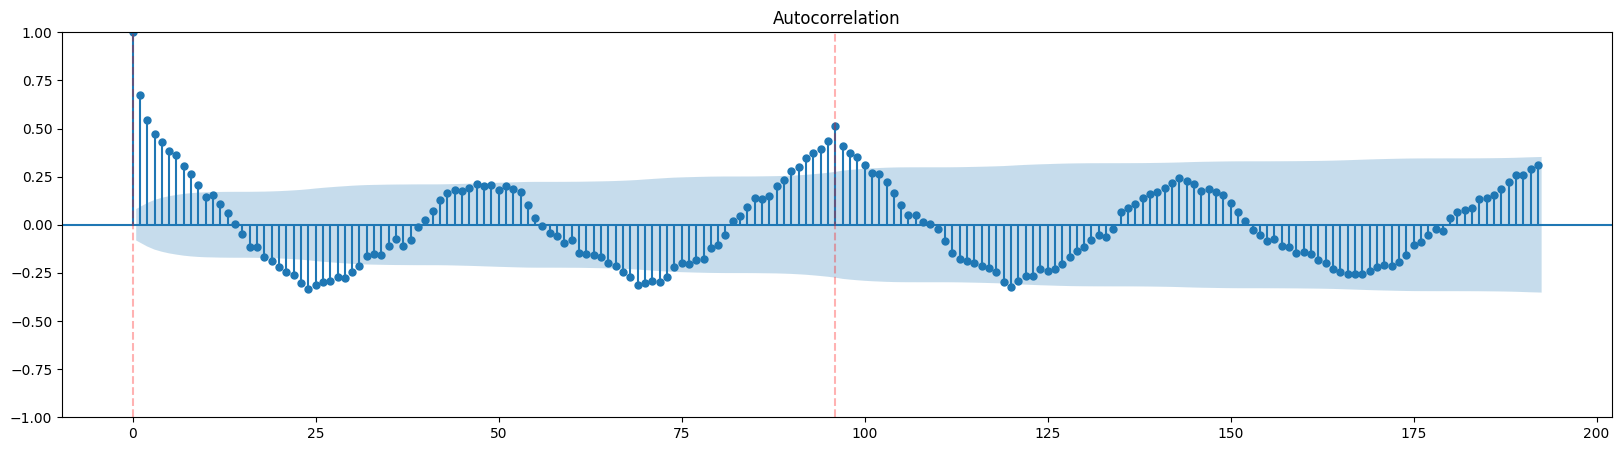

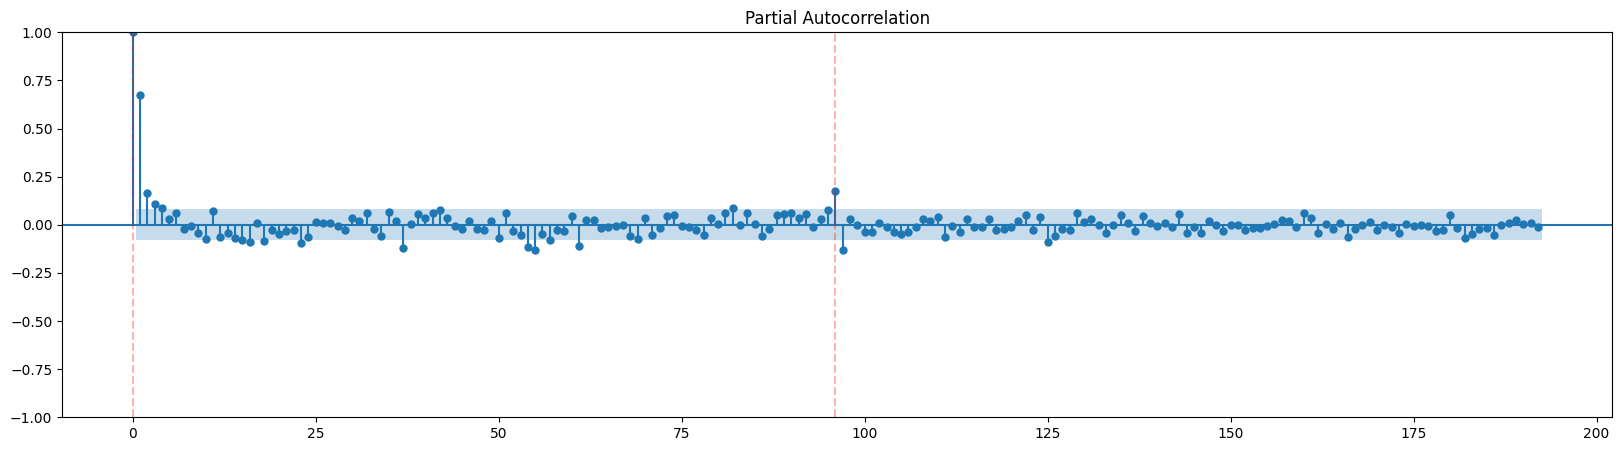

In [14]:
plot_load_data_acf_pacf(Load_df, 6, 2)

# Ice Cream Production Data

In [2]:
#read data
df_ice_cream = pd.read_csv('ice_cream.csv')

In [3]:
df_ice_cream.head()

,DATE,IPN31152N
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636


In [4]:
#rename columns to something more understandable
df_ice_cream.rename(columns={'DATE':'date', 'IPN31152N':'production'}, inplace=True)

In [5]:
#convert date column to datetime type
df_ice_cream['date'] = pd.to_datetime(df_ice_cream.date)

In [6]:
#set date as index
df_ice_cream.set_index('date', inplace=True)

In [24]:
#just get data from 2010 onwards
start_date = pd.to_datetime('2010-01-01')
df_ice_cream = df_ice_cream[start_date:]

In [25]:
#show result
df_ice_cream.head()

,production
date,
2010-01-01,91.2895
2010-02-01,110.4994
2010-03-01,127.0971
2010-04-01,132.6468
2010-05-01,134.5576


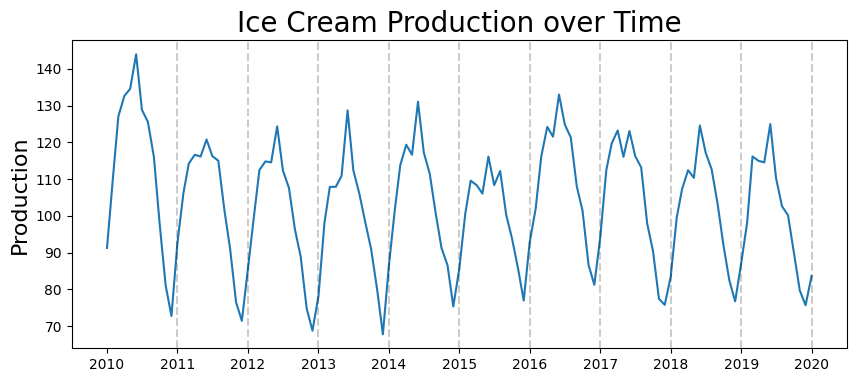

In [26]:
plt.figure(figsize=(10,4))
plt.plot(df_ice_cream.production)
plt.title('Ice Cream Production over Time', fontsize=20)
plt.ylabel('Production', fontsize=16)
for year in range(2011,2021):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

# ACF

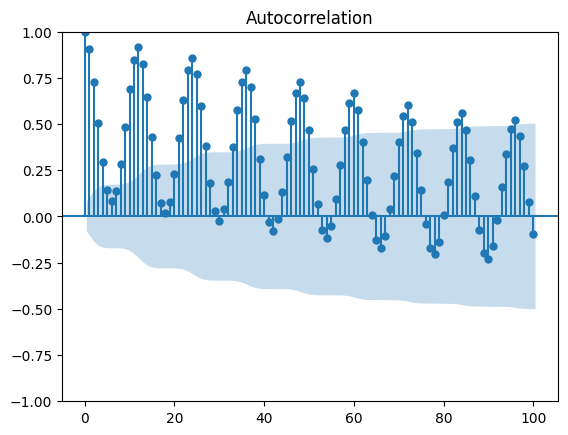

In [9]:
acf_plot = plot_acf(df_ice_cream.production, lags=100)

## Based on decaying ACF, we are likely dealing with an Auto Regressive process

# PACF

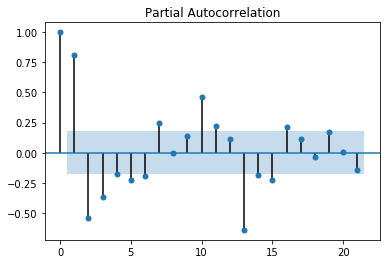

In [11]:
pacf_plot = plot_pacf(df_ice_cream.production)

## Based on PACF, we should start with an Auto Regressive model with lags 1, 2, 3, 10, 13

# On stock data

In [12]:
import yfinance as yf

In [13]:
#define the ticker symbol
tickerSymbol = 'SPY'

In [14]:
#get data on this ticker
tickerData = yf.Ticker(tickerSymbol)

In [15]:
#get the historical prices for this ticker
tickerDf = tickerData.history(period='1d', start='2015-1-1', end='2020-1-1')

In [16]:
tickerDf = tickerDf[['Close']]

In [17]:
#see your data
tickerDf.head()

,Close
Date,
2015-01-02,186.16
2015-01-05,182.80
2015-01-06,181.08
2015-01-07,183.33
2015-01-08,186.59


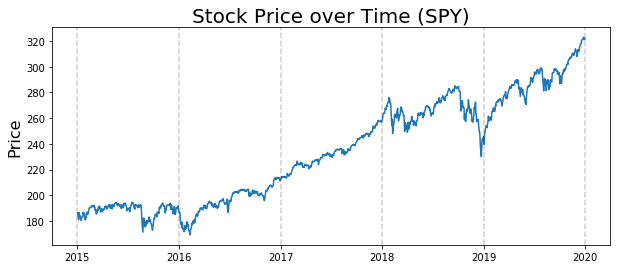

In [18]:
plt.figure(figsize=(10,4))
plt.plot(tickerDf.Close)
plt.title('Stock Price over Time (%s)'%tickerSymbol, fontsize=20)
plt.ylabel('Price', fontsize=16)
for year in range(2015,2021):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

## Stationarity: take first difference of this series

In [19]:
#take first difference
first_diffs = tickerDf.Close.values[1:] - tickerDf.Close.values[:-1]
first_diffs = np.concatenate([first_diffs, [0]])

In [20]:
#set first difference as variable in dataframe
tickerDf['FirstDifference'] = first_diffs

In [21]:
tickerDf.head()

,Close,FirstDifference
Date,,
2015-01-02,186.16,-3.36
2015-01-05,182.80,-1.72
2015-01-06,181.08,2.25
2015-01-07,183.33,3.26
2015-01-08,186.59,-1.50


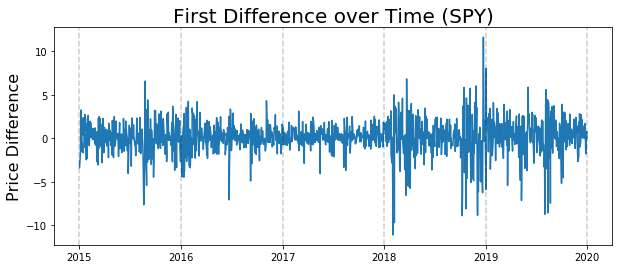

In [22]:
plt.figure(figsize=(10,4))
plt.plot(tickerDf.FirstDifference)
plt.title('First Difference over Time (%s)'%tickerSymbol, fontsize=20)
plt.ylabel('Price Difference', fontsize=16)
for year in range(2015,2021):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

# ACF

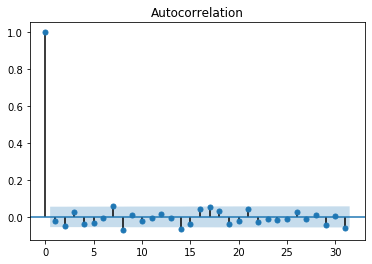

In [23]:
acf_plot = plot_acf(tickerDf.FirstDifference)

## ACF isn't that informative

# PACF

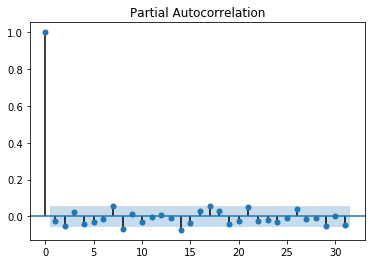

In [24]:
pacf_plot = plot_pacf(tickerDf.FirstDifference)

## PACF also doesn't tell us much